# PyHermes in Jupyter Notebook

#### README:
Choosing to use Jupyter Notebook, as you probably know, has its advantages: 

 - Intuitive and Convenient. 

However, the downside is that it doesn't support parallel computing, which means you can't fully leverage the power of pyhermes. 

Therefore, Jupyter Notebook is better suited for small-scale data testing, debugging, and similar purposes.

---

# Calculate convols

#### Calculate convols (<font color='orange'> calculate the `DeltaC` with parameters in file `params_convols.json`</font>)

##### <font color='red'>NOTICE:</font> Calculating `DeltaC` is the initial step for computing subsequent quantities, such as counting, 2PCF, and 3PCF.

The file of `param_convols.json` looks like:
```json 
{
 "Convols": {
    "J": 9,
    "fin": {
      "path": "https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin",
      "format": "generic"
    },
    "fout_dir": "./",
    "SampRate": 1024,
    "SimBoxL": 1000,
    "window_type": "shell",
    "wavelet_mode": "db2",
    "wavelet_level": 10,
    "Radius": 5,
    "bandwidth": 1,
    "threads": 2
  }
}

```

In [1]:
from pyhermes.base.convols import Convols
from pyhermes.param.parambase import read_param

In [2]:
param_input = read_param(config_path='param_convols.json')

deltac, pm = Convols(param_task=param_input).run(return_pData_rank0=True)

19:59:25 - INFO - pyhermes.param.parambase:JsonBase - Reading configure file: 'param_convols.json'
19:59:25 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <base> ...
19:59:25 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <base> ...
19:59:25 - INFO - pyhermes.param.parambase:JsonBase - Default 'Convols.fin.path' from './data.bin' to 'https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin'
19:59:25 - INFO - pyhermes.param.parambase:JsonBase - Default 'Convols.fout_dir' from 'empty' to './'
19:59:25 - INFO - pyhermes.param.parambase:JsonBase - Default 'Convols.window_type' from 'sphere' to 'shell'
19:59:25 - INFO - pyhermes.param.parambase:JsonBase - Default 'Convols.threads' from '5' to '2'

19:59:25 - INFO - pyhermes.pipeline.pipeline:Convols - The task will run on 1 MPI ranks
19:59:25 - INFO - pyhermes.io.funcs:read_particle_data - Selected input particle format: generic
19:59:25 - IN

In [3]:
deltac.data.sum()

406702.9084193025

In [4]:
print(deltac.data.shape)
print(type(deltac))

(512, 512, 512)
<class 'pyhermes.io.convols.ColvolsData'>


---

# Counting

#### Counting (<font color='orange'> Read DeltaC from path in `param_counting.json`</font>)

The file of `param_counting.json` looks like:
```json 
{
  "Counting": {
    "n_tasks": 100,
    "deltac_in_path": "./convols_L512_r5_pywt.npy",
    "fout_dir": "./"
  }
}

```

In [5]:
from pyhermes.theory.counting import Counting

param_input = read_param(config_path='param_counting.json')
counting = Counting(param_task=param_input).run()

19:59:43 - INFO - pyhermes.param.parambase:JsonBase - Reading configure file: 'param_counting.json'
19:59:43 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
19:59:43 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
19:59:43 - INFO - pyhermes.param.parambase:JsonBase - Default 'Counting.n_tasks' from '1000000' to '100'
19:59:43 - INFO - pyhermes.param.parambase:JsonBase - Default 'Counting.deltac_in_path' from 'empty' to './convols_L512_r5_pywt.npy'
19:59:43 - INFO - pyhermes.param.parambase:JsonBase - Default 'Counting.fout_dir' from 'empty' to './'

19:59:43 - INFO - pyhermes.pipeline.pipeline:Counting - The task will run on 1 MPI ranks
19:59:43 - INFO - pyhermes.io.base:CountingData - Reading DeltaC data from ---> ./convols_L512_r5_pywt.npy <---
19:59:44 - INFO - pyhermes.io.base:CountingData - DeltaC: Shape(512, 512, 512), Min = -0.0303, Max = 0.1416, Mean = 0.0030
19:59:44 - INFO - pyhermes.pipelin

#### Counting (<font color='orange'> Load DeltaC directly from the result of previous step, i.e., `deltac`</font>)

##### <font color='pink'>NOTICE:</font> 👇 
Using the `deltac=` argument in argv will override the `deltac_in_path` setting in `param_couting.json`.

In [6]:
from pyhermes.theory.counting import Counting

param_input = read_param(config_path='param_counting.json')
counting = Counting(param_task=param_input).run(deltac=deltac)

19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Reading configure file: 'param_counting.json'
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Default 'Counting.n_tasks' from '1000000' to '100'
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Default 'Counting.n_tasks' from '1000000' to '100'
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Default 'Counting.deltac_in_path' from 'empty' to './convols_L512_r5_pywt.npy'
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Default 'Counting.fout_dir' from 'empty' to './'

19:59:45 - INFO - pyhermes.pipeline.pipeline:Counting - The task will run on 1 MPI ranks
19:59:45 - INFO - pyhermes.pipeline.pipeline:Counting - Loading DeltaC from argument 'deltac'
19:59:45 - INFO - pyhermes.pipeline.pipeline:Counting - Start Counting

In [7]:
print(type(counting))

<class 'pyhermes.io.counting.CountingData'>


---

# Corr_2pcf

#### 2PCF (<font color='orange'> Read DeltaC from path in `param_2pcf.json`</font>)

The file of `param_2pcf.json` looks like:
```json 
{
  "Corr_2PCF": {
    "deltac_in_path": "./convols_L512_r5_pywt.npy",
    "fout_dir": "./",
    "threads": 20,
    "R1": 1.0,
    "R2": 150.0,
    "xi_num": 30
  }
}
```

In [8]:
from pyhermes.theory.corr2pcf import Corr_2PCF

param_input = read_param(config_path='param_2pcf.json')

# You can modify your parameters any time, in the style of dict:
param_input['Corr_2PCF']['xi_num'] = 20
corr_2pcf = Corr_2PCF(param_task=param_input).run()

19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Reading configure file: 'param_2pcf.json'
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.deltac_in_path' from 'empty' to './convols_L512_r5_pywt.npy'
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.fout_dir' from 'empty' to './'
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.threads' from '5' to '20'
19:59:45 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.xi_num' from '150' to '20'

19:59:45 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - The task will run on 1 MPI ranks
19:59:45 - INFO - pyhermes.io.base:Corr2PCFData - Reading DeltaC data from ---> ./convols_L512_r5_pywt.npy <---
19:59:46 - INFO - pyhermes.io.base:Corr2PCFData - DeltaC: Shape(

#### 2PCF (<font color='orange'> Load DeltaC directly from the result of previous step, i.e., `deltac`)

##### <font color='pink'>NOTICE:</font> 👇 
Using the `deltac=` argument in argv will override the `deltac_in_path` setting in `param_2pcf.json`.

In [9]:
from pyhermes.theory.corr2pcf import Corr_2PCF

param_input = read_param(config_path='param_2pcf.json')

# You can modify your parameters any time, in the style of dict:
param_input['Corr_2PCF']['xi_num'] = 20
corr_2pcf = Corr_2PCF(param_task=param_input).run(deltac=deltac)

20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Reading configure file: 'param_2pcf.json'
20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.deltac_in_path' from 'empty' to './convols_L512_r5_pywt.npy'
20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.fout_dir' from 'empty' to './'
20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.threads' from '5' to '20'
20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.xi_num' from '150' to '20'
20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.deltac_in_path' from 'empty' to './convols_L512_r5_pywt.npy'
20:00:22 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_2PCF.fout_dir' from 'empty' to './'
20:00:22 - INFO - pyhermes.pa

In [10]:
print(type(corr_2pcf))

<class 'pyhermes.io.corr2pcf.Corr2PCFData'>


20:00:56 - INFO - pyhermes.pipeline.pipeline:Counting - Bye.


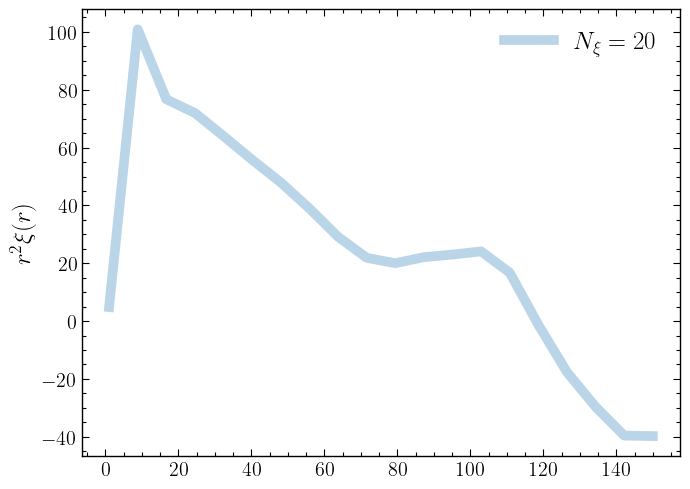

In [11]:
import matplotlib.pyplot as plt

xi_num = param_input['Corr_2PCF']['xi_num']

plt.figure(figsize=(7, 5))
plt.plot(corr_2pcf.r, corr_2pcf.xi * corr_2pcf.r**2, label=rf'$N_\xi={xi_num}$', lw=7, alpha=0.3)
plt.ylabel(r'$r^2 \xi(r)$', fontsize='18')
plt.legend(loc='best', fontsize='18')

#### <font color='#29bfef'>Tips:</font> Save the 2PCF data anytime
If you leave `fout_dir` empty in the `param_2pcf.json` file, by default, the 2PCF results will not be saved. However, you can use `.save` to save them at any time.

In [12]:
corr_2pcf.save('./what_ever_any_folder/any_filename')

20:00:57 - INFO - pyhermes.io.base:Corr2PCFData - Writing data to ---> ./what_ever_any_folder/any_filename <---


#### <font color='#29bfef'>Tips:</font> Load the 2PCF data anytime
You can load the 2PCF data from the results of a previous run's output anytime, then generate the corresponding plot.

In [13]:
from pyhermes.io import Corr2PCFData

corr_2pcf_pre = Corr2PCFData()

In [14]:
corr_2pcf_pre.load("./demo_data/corr2pcf_r5_xinum200.txt")

20:00:58 - INFO - pyhermes.io.base:Corr2PCFData - Reading data from ---> ./demo_data/corr2pcf_r5_xinum200.txt <---


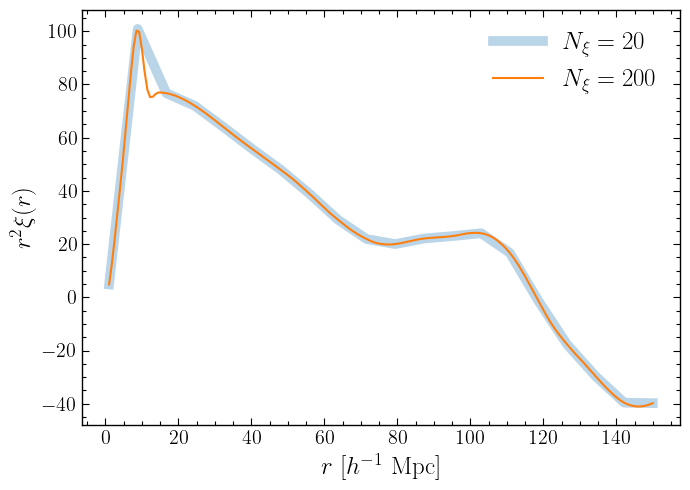

In [15]:
import matplotlib.pyplot as plt

xi_num_pre = 200

plt.figure(figsize=(7, 5))
plt.plot(corr_2pcf.r, corr_2pcf.xi * corr_2pcf.r**2, label=rf'$N_\xi={xi_num}$', lw=7, alpha=0.3)
plt.plot(corr_2pcf_pre.r, corr_2pcf_pre.xi * corr_2pcf_pre.r**2, label=rf'$N_\xi={xi_num_pre}$')
plt.xlabel(r'$r\ [h^{-1}\ \mathrm{Mpc}]$', fontsize='18')
plt.ylabel(r'$r^2 \xi(r)$', fontsize='18')
plt.legend(loc='best', fontsize='18')

---

# Corr_3PCF

#### 3PCF (<font color='orange'> Read DeltaC from path in `param_3pcf.json`</font>)

The file of `param_3pcf.json` looks like:
```json 
{
  "Corr_3PCF": {
    "fin": {
      "path": "https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin",
      "format": "generic"
    },
    "deltac_in_path": "./convols_L512_r5_pywt.npy",
    "fout_dir": "./",
    "NStheta": 20,
    "R1": 20.0,
    "R2": 40.0,
    "rot_num": 3
  }
}
```

In [16]:
from pyhermes.theory.corr3pcf import Corr_3PCF

param_input = read_param(config_path='param_3pcf.json')

# You can modify your parameters any time, in the style of dict:
param_input['Corr_3PCF']['rot_num'] = 3

corr_3pcf = Corr_3PCF(param_task=param_input).run()

20:00:58 - INFO - pyhermes.param.parambase:JsonBase - Reading configure file: 'param_3pcf.json'
20:00:58 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
20:00:58 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
20:00:58 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_3PCF.fin.path' from './data.bin' to 'https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin'
20:00:58 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_3PCF.deltac_in_path' from 'empty' to './convols_L512_r5_pywt.npy'
20:00:58 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_3PCF.fout_dir' from 'empty' to './'
20:00:58 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_3PCF.rot_num' from '10000' to '3'

20:00:58 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - The task will run on 1 MPI ranks
20:00:58 - INFO - pyhermes.io.base:Corr3PCFData - Reading DeltaC data fr

#### 3PCF (<font color='orange'> Load DeltaC and particle data directly from the result of previous step, i.e., `deltac` and `p_dm`)

##### <font color='pink'>NOTICE:</font> 👇 
- Using the `deltac=` and `p_dm=` arguments in argv will override the `deltac_in_path` and `fin-path` settings in `param_3pcf.json`.
- To load particle data with `p_dm=`, ensure you set `return_pData_rank0=True` when calculating `deltac`. If `return_pData_rank0=True` is not specified, only `deltac` will be returned. For example:
```python
deltac, pm = Convols(param_task=param_input).run(return_pData_rank0=True)
```

In [17]:
print(pm.shape)
print(type(pm))

(406793, 3)
<class 'numpy.ndarray'>


In [18]:
from pyhermes.theory.corr3pcf import Corr_3PCF

param_input = read_param(config_path='param_3pcf.json')

# You can modify your parameters any time, in the style of dict:
param_input['Corr_3PCF']['rot_num'] = 3

corr_3pcf = Corr_3PCF(param_task=param_input).run(deltac=deltac, p_dm=pm)

20:01:39 - INFO - pyhermes.param.parambase:JsonBase - Reading configure file: 'param_3pcf.json'
20:01:39 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
20:01:39 - INFO - pyhermes.param.parambase:JsonBase - Set default parameters of module <theory> ...
20:01:39 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_3PCF.fin.path' from './data.bin' to 'https://pyhermes.astroslacker.com/_downloads/906e0695649e3634a5fe8081b9ab2086/quijote10000.bin'
20:01:39 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_3PCF.deltac_in_path' from 'empty' to './convols_L512_r5_pywt.npy'
20:01:39 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_3PCF.fout_dir' from 'empty' to './'
20:01:39 - INFO - pyhermes.param.parambase:JsonBase - Default 'Corr_3PCF.rot_num' from '10000' to '3'

20:01:39 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - The task will run on 1 MPI ranks
20:01:39 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - Loading DeltaC 

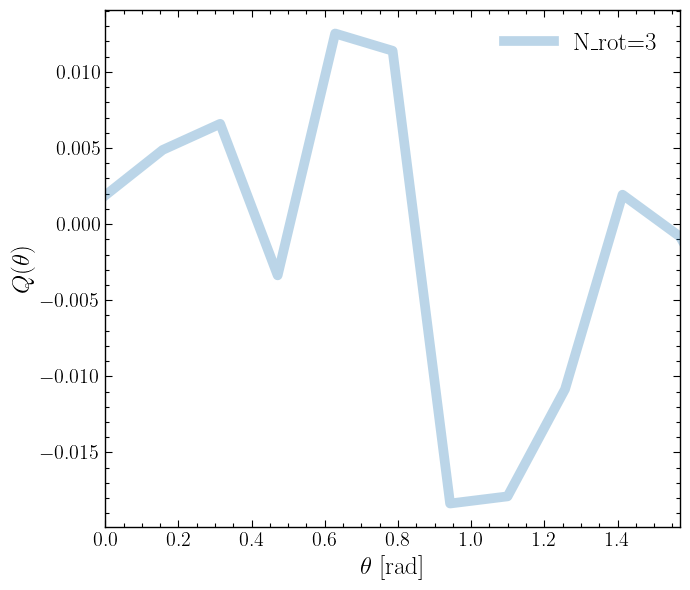

In [19]:
import numpy as np
import matplotlib.pyplot as plt

N_rot = param_input['Corr_3PCF']['rot_num']

plt.figure(figsize=(7,6))
plt.plot(corr_3pcf.theta, corr_3pcf.Q, label=rf'N_rot={N_rot}', lw=7, alpha=0.3)
plt.xlabel(r'$\theta\ [\mathrm{rad}]$', fontsize='18')
plt.ylabel(r'$Q(\theta)$', fontsize='18')
plt.xlim(0., np.pi/2.)
plt.legend(loc='best', fontsize='18')

#### <font color='#29bfef'>Tips:</font> Save the 3PCF data anytime
If you leave `fout_dir` empty in the `param_3pcf.json` file, by default, the 3PCF results will not be saved. However, you can use `.save` to save them at any time.

In [20]:
corr_3pcf.save('./what_ever_any_folder/any_filename')

20:02:08 - INFO - pyhermes.io.base:Corr3PCFData - Writing data to ---> ./what_ever_any_folder/any_filename <---


#### <font color='#29bfef'>Tips:</font> Load the 3PCF data anytime
You can load the 3PCF data from the results of a previous run's output anytime, then generate the corresponding plot.

In [21]:
from pyhermes.io import Corr3PCFData

corr_3pcf_pre = Corr3PCFData()

In [22]:
corr_3pcf_pre.load("./demo_data/corr3pcf_r5_R1.20.0_R2.40.0_rotN10000.txt")

20:02:08 - INFO - pyhermes.io.base:Corr3PCFData - Reading data from ---> ./demo_data/corr3pcf_r5_R1.20.0_R2.40.0_rotN10000.txt <---


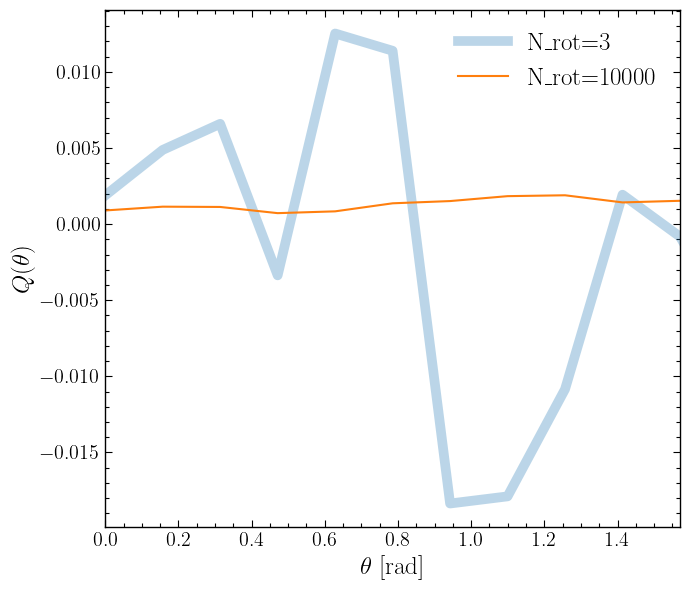

In [23]:
import numpy as np
import matplotlib.pyplot as plt

N_rot_pre = 10000

plt.figure(figsize=(7,6))
plt.plot(corr_3pcf.theta, corr_3pcf.Q, label=rf'N_rot={N_rot}', lw=7, alpha=0.3)
plt.plot(corr_3pcf_pre.theta, corr_3pcf_pre.Q, label=rf'N_rot={N_rot_pre}')
plt.xlabel(r'$\theta\ [\mathrm{rad}]$', fontsize='18')
plt.ylabel(r'$Q(\theta)$', fontsize='18')
plt.xlim(0., np.pi/2.)
plt.legend(loc='best', fontsize='18')